KDE‐based mean σ_zz = 67.38 ppm
KDE‐based  SD σ_zz = 12.65 ppm


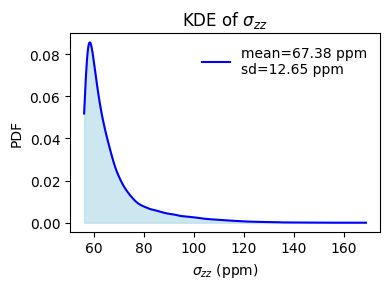

θ distribution: mean=89.1°, sd=12.5°


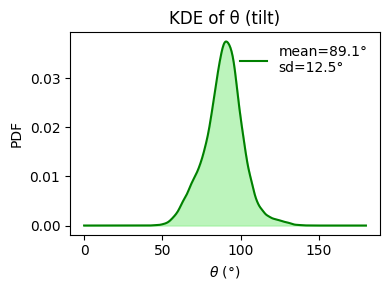

φ distribution: mean=118.5°, sd=65.9°


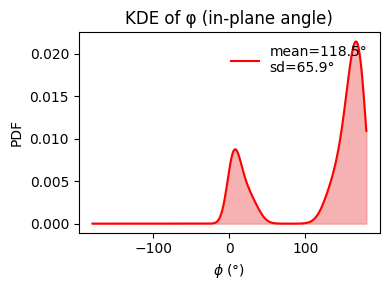

Saved σ, θ, φ distributions to /home/ebam/ravi1/results/


In [11]:
import os
import numpy as np
import pandas as pd
import MDAnalysis as mda
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ── User parameters ──
data_dir = '/home/ebam/ravi1/phd/14A_apoa1/new_apporach/new/12_dimers/cubic_bigbox/charmm-gui-9583052457/gromacs/dired_fixed_orient/37_degree/res_tails'
gro_name  = 'step5_1.gro'
xtc_names = [
    '',
]
gro_file  = os.path.join(data_dir, gro_name)
xtc_files = [os.path.join(data_dir, fn) for fn in xtc_names]

residue_number = 5 # 1‐based index within each peptide copy
copies         = 24

# ── CSA principal values (ppm) and β = 16° ──
sigma11, sigma22, sigma33 = 56.0, 81.0, 223.0
beta_rad       = np.deg2rad(16.0)

# ── Membrane normals ──
n_mem_pos = np.array([0.0, 0.0, 1.0])
n_mem_neg = -n_mem_pos

# ── Helper functions ──
def normalize(v):
    norm = np.linalg.norm(v)
    return v / norm if norm > 1e-8 else v

def rotate_about_axis(v, axis, angle):
    """
    Rotate vector v around unit‐axis 'axis' by 'angle' (radians),
    using Rodrigues’ rotation formula.
    """
    axis = normalize(axis)
    cosA = np.cos(angle)
    sinA = np.sin(angle)
    return (
        v*cosA 
        + np.cross(axis, v)*sinA 
        + axis*(np.dot(axis, v))*(1 - cosA)
    )

def calc_principal_axes(prev_res, cur_res, n_mem):
    """
    Build orthonormal axes {e_11, e_22, e_33}:
      - e_22 (σ₂₂) = peptide‐plane normal from (C_prev, N_cur, O_prev).
      - Project N–H and N–C onto that plane.
      - e_33 (σ₃₃) = rotate in‐plane N–H by +16° toward in‐plane N–C.
      - e_11 (σ₁₁) = e_22 × e_33.
    Returns (e_11, e_22, e_33).
    """
    Npos = cur_res.atoms.select_atoms("name N")[0].position
    Hpos = cur_res.atoms.select_atoms("name HN or name H")[0].position
    Cpos = prev_res.atoms.select_atoms("name C")[0].position
    Opos = prev_res.atoms.select_atoms("name O")[0].position

    # Raw bond vectors
    raw_e_NH = Hpos - Npos
    raw_e_NC = Cpos - Npos

    # (1) Peptide‐plane normal from (C_prev, N_cur, O_prev)
    v_CN = Cpos - Npos
    v_ON = Opos - Npos
    e_plane = normalize(np.cross(v_CN, v_ON))
    # Ensure e_plane · n_mem ≥ 0
    if np.dot(e_plane, n_mem) < 0:
        e_plane = -e_plane

    # (2) Project N–H and N–C onto that plane
    proj_NH = raw_e_NH - np.dot(raw_e_NH, e_plane)*e_plane
    proj_NC = raw_e_NC - np.dot(raw_e_NC, e_plane)*e_plane
    e_NH_plane = normalize(proj_NH)
    e_NC_plane = normalize(proj_NC)

    # (3) e_33: rotate e_NH_plane by +β toward e_NC_plane
    sign = np.sign(np.dot(e_plane, np.cross(e_NH_plane, e_NC_plane)))
    e_33 = normalize(rotate_about_axis(e_NH_plane, e_plane, sign * beta_rad))

    # (4) e_11: in‐plane ⟂ e_33
    e_11 = normalize(np.cross(e_plane, e_33))

    # (5) e_22: plane normal
    e_22 = e_plane

    return e_11, e_22, e_33

def calc_angles_and_sigma(e_11, e_22, e_33, n_mem):
    """
    Compute angles θ, φ and then σ_zz using:
      θ = angle(e_33, n_mem)
      φ = angle between e_11 and projection of n_mem into plane ⟂ e_33
      σ_zz = σ₁₁ sin²θ cos²φ + σ₂₂ sin²θ sin²φ + σ₃₃ cos²θ
    Returns (sigma_zz, theta_rad, phi_rad).
    """
    # θ = arccos(e_33 · n_mem)
    cos_theta = np.clip(np.dot(e_33, n_mem), -1.0, 1.0)
    theta = np.arccos(cos_theta)

    # Project n_mem into plane perpendicular to e_33
    n_proj = n_mem - cos_theta * e_33
    e_nproj = normalize(n_proj)

    # φ: in‐plane angle between e_11 and e_nproj
    cos_phi = np.clip(np.dot(e_11, e_nproj), -1.0, 1.0)
    sin_phi = np.clip(np.dot(e_22, e_nproj), -1.0, 1.0)
    phi = np.arctan2(sin_phi, cos_phi)

    # Now σ_zz via the angle formula
    sin2_t = np.sin(theta)**2
    cos2_t = np.cos(theta)**2
    sin2_p = np.sin(phi)**2
    cos2_p = np.cos(phi)**2

    sigma_zz = (
        sigma11 * sin2_t * cos2_p
      + sigma22 * sin2_t * sin2_p
      + sigma33 * cos2_t
    )
    return sigma_zz, theta, phi

# ── Load Universe & split into peptide copies ──
u = mda.Universe(gro_file, xtc_files)
all_res = list(u.select_atoms("protein").residues)
residues_per_copy = len(all_res) // copies
if len(all_res) % copies != 0:
    raise ValueError(f"len(all_res)={len(all_res)} not divisible by copies={copies}")

peptide_blocks = [
    all_res[i*residues_per_copy : (i+1)*residues_per_copy]
    for i in range(copies)
]
copy_pairs = [
    (peptide_blocks[i], peptide_blocks[i+1])
    for i in range(0, copies, 2)
]

sigma_vals    = []
theta_vals     = []
phi_vals       = []

# ── Loop over all frames ──
for ts in u.trajectory:
    for (block1, block2) in copy_pairs:
        if residue_number-1 >= residues_per_copy:
            raise IndexError(f"residue_number={residue_number} out of range")

        # Block1: membrane normal = +Z
        prev1, cur1 = block1[residue_number-2], block1[residue_number-1]
        e11_1, e22_1, e33_1 = calc_principal_axes(prev1, cur1, n_mem_pos)
        sig1, th1, ph1 = calc_angles_and_sigma(e11_1, e22_1, e33_1, n_mem_pos)
        sigma_vals.append(sig1)
        theta_vals.append(th1)
        phi_vals.append(ph1)

        # Block2: membrane normal = −Z
        prev2, cur2 = block2[residue_number-2], block2[residue_number-1]
        e11_2, e22_2, e33_2 = calc_principal_axes(prev2, cur2, n_mem_neg)
        sig2, th2, ph2 = calc_angles_and_sigma(e11_2, e22_2, e33_2, n_mem_neg)
        sigma_vals.append(sig2)
        theta_vals.append(th2)
        phi_vals.append(ph2)

sigma_vals = np.array(sigma_vals)
theta_vals = np.array(theta_vals)  # in radians
phi_vals   = np.array(phi_vals)    # in radians

# ── Build KDE (σ) and normalize to a PDF ──
kde_sigma = gaussian_kde(sigma_vals)
x_s = np.linspace(sigma_vals.min(), sigma_vals.max(), 500)
y_s = kde_sigma(x_s)
pdf_sigma = y_s / np.trapz(y_s, x_s)

mean_kde = np.trapz(x_s * pdf_sigma, x_s)
sd_kde   = np.sqrt(np.trapz((x_s - mean_kde)**2 * pdf_sigma, x_s))

print(f"KDE‐based mean σ_zz = {mean_kde:.2f} ppm")
print(f"KDE‐based  SD σ_zz = {sd_kde:.2f} ppm")

# ── Plot σ_zz distribution ──
plt.figure(figsize=(4,3))
plt.fill_between(x_s, pdf_sigma, color='lightblue', alpha=0.6)
plt.plot(x_s, pdf_sigma, color='blue',
         label=f"mean={mean_kde:.2f} ppm\nsd={sd_kde:.2f} ppm")
plt.xlabel(r'$\sigma_{zz}$ (ppm)')
plt.ylabel('PDF')
plt.title('KDE of $\sigma_{zz}$')
plt.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

# ── (Optional) Convert angles to degrees & save distributions ──
theta_deg = np.degrees(theta_vals)
phi_deg   = np.degrees(phi_vals)

# KDE for θ
kde_th = gaussian_kde(theta_deg)
x_th = np.linspace(0, 180, 500)
y_th = kde_th(x_th)
pdf_th = y_th / np.trapz(y_th, x_th)
mean_th = np.trapz(x_th * pdf_th, x_th)
sd_th   = np.sqrt(np.trapz((x_th - mean_th)**2 * pdf_th, x_th))
print(f"θ distribution: mean={mean_th:.1f}°, sd={sd_th:.1f}°")

plt.figure(figsize=(4,3))
plt.fill_between(x_th, pdf_th, color='lightgreen', alpha=0.6)
plt.plot(x_th, pdf_th, color='green',
         label=f"mean={mean_th:.1f}°\nsd={sd_th:.1f}°")
plt.xlabel(r'$\theta$ (°)')
plt.ylabel('PDF')
plt.title('KDE of θ (tilt)')
plt.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

# KDE for φ
kde_ph = gaussian_kde(phi_deg)
x_ph = np.linspace(-180, 180, 500)
y_ph = kde_ph(x_ph)
pdf_ph = y_ph / np.trapz(y_ph, x_ph)
mean_ph = np.trapz(x_ph * pdf_ph, x_ph)
sd_ph   = np.sqrt(np.trapz((x_ph - mean_ph)**2 * pdf_ph, x_ph))
print(f"φ distribution: mean={mean_ph:.1f}°, sd={sd_ph:.1f}°")

plt.figure(figsize=(4,3))
plt.fill_between(x_ph, pdf_ph, color='lightcoral', alpha=0.6)
plt.plot(x_ph, pdf_ph, color='red',
         label=f"mean={mean_ph:.1f}°\nsd={sd_ph:.1f}°")
plt.xlabel(r'$\phi$ (°)')
plt.ylabel('PDF')
plt.title('KDE of φ (in‐plane angle)')
plt.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

# ── Save distributions to CSV ──
outdir = '/home/ebam/ravi1/results/'
os.makedirs(outdir, exist_ok=True)
df_sigma = pd.DataFrame({'sigma_zz': x_s, 'pdf_sigma': pdf_sigma})
df_theta = pd.DataFrame({'theta_deg': x_th, 'pdf_theta': pdf_th})
df_phi   = pd.DataFrame({'phi_deg':   x_ph, 'pdf_phi':   pdf_ph})
df_sigma.to_csv(os.path.join(outdir, 'sigma_distribution.csv'), index=False)
df_theta.to_csv(os.path.join(outdir, 'theta_distribution.csv'), index=False)
df_phi.to_csv(os.path.join(outdir, 'phi_distribution.csv'), index=False)
print(f"Saved σ, θ, φ distributions to {outdir}")


Frame 0, Pair 0, Block1: residue ALA5
Frame 0, Pair 0, Block2: residue ALA5
Frame 0, Pair 1, Block1: residue ALA5
Frame 0, Pair 1, Block2: residue ALA5
Frame 0, Pair 2, Block1: residue ALA5
Frame 0, Pair 2, Block2: residue ALA5
Frame 0, Pair 3, Block1: residue ALA5
Frame 0, Pair 3, Block2: residue ALA5
Frame 0, Pair 4, Block1: residue ALA5
Frame 0, Pair 4, Block2: residue ALA5
Frame 0, Pair 5, Block1: residue ALA5
Frame 0, Pair 5, Block2: residue ALA5
Frame 0, Pair 6, Block1: residue ALA5
Frame 0, Pair 6, Block2: residue ALA5
Frame 0, Pair 7, Block1: residue ALA5
Frame 0, Pair 7, Block2: residue ALA5
Frame 0, Pair 8, Block1: residue ALA5
Frame 0, Pair 8, Block2: residue ALA5
Frame 0, Pair 9, Block1: residue ALA5
Frame 0, Pair 9, Block2: residue ALA5
Frame 0, Pair 10, Block1: residue ALA5
Frame 0, Pair 10, Block2: residue ALA5
Frame 0, Pair 11, Block1: residue ALA5
Frame 0, Pair 11, Block2: residue ALA5
Frame 1, Pair 0, Block1: residue ALA5
Frame 1, Pair 0, Block2: residue ALA5
Frame 1,

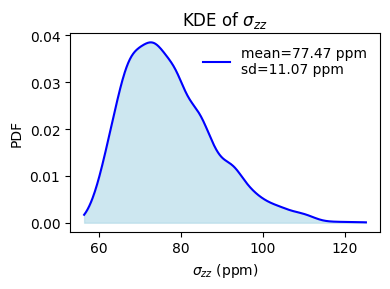

θ distribution: mean=73.1°, sd=6.9°


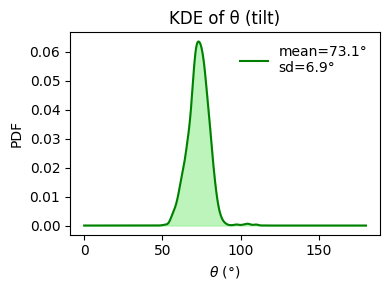

φ distribution: mean=27.5°, sd=12.4°


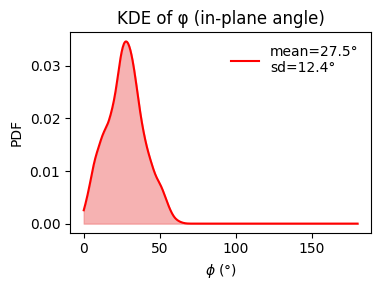

Saved σ, θ, φ distributions to /home/ebam/ravi1/results/system_b/chemical_shift/glob_37/leu10


In [4]:
import os
import numpy as np
import pandas as pd
import MDAnalysis as mda
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ── User parameters ──
# Base folder where all your gro/xtc files live
data_dir = '/home/ebam/ravi1/phd/14A_apoa1/new_apporach/new/12_dimers/cubic_bigbox/charmm-gui-9583052457/gromacs/dired_fixed_orient/37_degree/res_tails'

# Just the filenames (no paths) — change these as needed
gro_name  = 'step5_1.gro'
xtc_names = [
'/home/ebam/ravi1/phd/14A_apoa1/new_apporach/new/12_dimers/cubic_bigbox/charmm-gui-9583052457/gromacs/dired_fixed_orient/37_degree/res_tails/step5_2.xtc',

]
gro_file  = os.path.join(data_dir, gro_name)
xtc_files = [os.path.join(data_dir, fn) for fn in xtc_names]

residue_number = 5 # 1‐based index within each peptide copy
copies         = 24

# ── CSA principal values (ppm) and β = 16° ──
sigma11, sigma22, sigma33 = 56.0, 81.0, 223.0
beta_rad       = np.deg2rad(16.0)

# ── Membrane normals ──
n_mem_pos = np.array([0.0, 0.0, -1.0])
n_mem_neg = -n_mem_pos

# ── Helper functions ──
def normalize(v):
    norm = np.linalg.norm(v)
    return v / norm if norm > 1e-8 else v

def rotate_about_axis(v, axis, angle):
    """
    Rotate vector v around unit‐axis 'axis' by 'angle' (radians),
    using Rodrigues’ rotation formula.
    """
    axis = normalize(axis)
    cosA = np.cos(angle)
    sinA = np.sin(angle)
    return (
        v * cosA
        + np.cross(axis, v) * sinA
        + axis * (np.dot(axis, v)) * (1 - cosA)
    )

def calc_principal_axes(prev_res, cur_res, n_mem):
    """
    Build orthonormal axes {e_11, e_22, e_33} such that
      • e_22 (σ₂₂) = peptide‐plane normal from (C_prev, N_cur, O_prev).
      • e_11 (σ₁₁) = the projection of N–C onto that plane.
      • e_33 (σ₃₃) = e_11 × e_22 (to complete the right‐handed frame).
    Returns (e_11, e_22, e_33).
    """
    # 1) Atom positions
    Npos = cur_res.atoms.select_atoms("name N")[0].position
    Hpos = cur_res.atoms.select_atoms("name HN or name H")[0].position
    Cpos = prev_res.atoms.select_atoms("name C")[0].position
    Opos = prev_res.atoms.select_atoms("name O")[0].position

    # 2) Raw bond vectors
    raw_e_NH = Hpos - Npos
    raw_e_NC = Cpos - Npos

    # 3) Peptide‐plane normal (σ₂₂) from (C_prev, N_cur, O_prev)
    v_CN = Cpos - Npos
    v_ON = Opos - Npos
    e_plane = normalize(np.cross(v_CN, v_ON))
    if np.dot(e_plane, n_mem) < 0:
        e_plane = -e_plane
    e_22 = e_plane

    # 4) Project N–C onto that plane → e_NC_plane
    proj_NC = raw_e_NC - np.dot(raw_e_NC, e_plane) * e_plane
    e_NC_plane = normalize(proj_NC)

    # 5) Define e_11 to lie along the NC bond direction (in‐plane)
    e_11 = e_NC_plane

    # 6) Complete right‐handed set: e_33 = cross(e_11, e_22)
    e_33 = normalize(np.cross(e_11, e_22))

    return e_11, e_22, e_33

def calc_angles_and_sigma(e_11, e_22, e_33, n_mem):
    """
    Compute θ, φ (both in radians) and then σ_zz:
      θ = arccos(e_33 · n_mem)  in [0, π]
      Project n_mem into plane ⟂ e_33 to get n_perp.
      φ = arccos( e_11 · n_perp ) in [0, π]
      σ_zz = σ₁₁ sin²θ cos²φ + σ₂₂ sin²θ sin²φ + σ₃₃ cos²θ.

    Returns (sigma_zz, θ, φ).
    """
    # θ = arccos(e_33 · n_mem)
    cos_theta = np.clip(np.dot(e_33, n_mem), -1.0, 1.0)
    theta = np.arccos(cos_theta)

    # Project n_mem into plane perpendicular to e_33
    n_proj = n_mem - cos_theta * e_33
    e_nproj = normalize(n_proj)

    # φ_raw = arccos(e_11 · e_nproj), which lies in [0, π]
    cos_phi = np.clip(np.dot(e_11, e_nproj), -1.0, 1.0)
    phi_raw = np.arccos(cos_phi)

    # fold φ into [0, π/2]
    if phi_raw > (np.pi/2):
        phi = np.pi - phi_raw
    else:
        phi = phi_raw

    # Now compute σ_zz via the angle formula
    sin2_t = np.sin(theta)**2
    cos2_t = np.cos(theta)**2
    sin2_p = np.sin(phi)**2
    cos2_p = np.cos(phi)**2

    sigma_zz = (
        sigma11 * sin2_t * cos2_p
      + sigma22 * sin2_t * sin2_p
      + sigma33 * cos2_t
    )
    return sigma_zz, theta, phi

# ── Load Universe & split into peptide copies ──
u = mda.Universe(gro_file, xtc_files)
all_res = list(u.select_atoms("protein").residues)
residues_per_copy = len(all_res) // copies
if len(all_res) % copies != 0:
    raise ValueError(f"len(all_res)={len(all_res)} is not divisible by copies={copies}")

peptide_blocks = [
    all_res[i*residues_per_copy : (i+1)*residues_per_copy]
    for i in range(copies)
]
copy_pairs = [
    (peptide_blocks[i], peptide_blocks[i+1])
    for i in range(0, copies, 2)
]

sigma_vals = []
theta_vals = []
phi_vals   = []

# ── Loop over all frames ──
for ts in u.trajectory:
    for pair_index, (block1, block2) in enumerate(copy_pairs):
        if residue_number-1 >= residues_per_copy:
            raise IndexError(f"residue_number={residue_number} out of range")

        # Block1 (membrane normal = +Z)
        prev1, cur1 = block1[residue_number-2], block1[residue_number-1]
        print(f"Frame {ts.frame}, Pair {pair_index}, Block1: residue {cur1.resname}{cur1.resid}")
        e11_1, e22_1, e33_1 = calc_principal_axes(prev1, cur1, n_mem_pos)
        sig1, th1, ph1 = calc_angles_and_sigma(e11_1, e22_1, e33_1, n_mem_pos)
        sigma_vals.append(sig1)
        theta_vals.append(th1)
        phi_vals.append(ph1)

        # Block2 (membrane normal = −Z)
        prev2, cur2 = block2[residue_number-2], block2[residue_number-1]
        print(f"Frame {ts.frame}, Pair {pair_index}, Block2: residue {cur2.resname}{cur2.resid}")
        e11_2, e22_2, e33_2 = calc_principal_axes(prev2, cur2, n_mem_neg)
        sig2, th2, ph2 = calc_angles_and_sigma(e11_2, e22_2, e33_2, n_mem_neg)
        sigma_vals.append(sig2)
        theta_vals.append(th2)
        phi_vals.append(ph2)

# Convert to NumPy arrays
sigma_vals = np.array(sigma_vals)
theta_vals = np.array(theta_vals)  # in radians
phi_vals   = np.array(phi_vals)    # in radians

# ── Build KDE (σ) and normalize to a PDF ──
kde_sigma = gaussian_kde(sigma_vals)
x_s = np.linspace(sigma_vals.min(), sigma_vals.max(), 500)
y_s = kde_sigma(x_s)
pdf_sigma = y_s / np.trapz(y_s, x_s)

mean_kde = np.trapz(x_s * pdf_sigma, x_s)
sd_kde   = np.sqrt(np.trapz((x_s - mean_kde)**2 * pdf_sigma, x_s))

print(f"KDE‐based mean σ_zz = {mean_kde:.2f} ppm")
print(f"KDE‐based  SD σ_zz = {sd_kde:.2f} ppm")

# ── Plot σ_zz distribution ──
plt.figure(figsize=(4, 3))
plt.fill_between(x_s, pdf_sigma, color='lightblue', alpha=0.6)
plt.plot(x_s, pdf_sigma, color='blue',
         label=f"mean={mean_kde:.2f} ppm\nsd={sd_kde:.2f} ppm")
plt.xlabel(r'$\sigma_{zz}$ (ppm)')
plt.ylabel('PDF')
plt.title('KDE of $\sigma_{zz}$')
plt.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

# ── Convert angles to degrees & save distributions ──
theta_deg = np.degrees(theta_vals)
phi_deg   = np.degrees(phi_vals)

# KDE for θ
kde_th = gaussian_kde(theta_deg)
x_th = np.linspace(0, 180, 500)
y_th = kde_th(x_th)
pdf_th = y_th / np.trapz(y_th, x_th)
mean_th = np.trapz(x_th * pdf_th, x_th)
sd_th   = np.sqrt(np.trapz((x_th - mean_th)**2 * pdf_th, x_th))
print(f"θ distribution: mean={mean_th:.1f}°, sd={sd_th:.1f}°")

plt.figure(figsize=(4, 3))
plt.fill_between(x_th, pdf_th, color='lightgreen', alpha=0.6)
plt.plot(x_th, pdf_th, color='green',
         label=f"mean={mean_th:.1f}°\nsd={sd_th:.1f}°")
plt.xlabel(r'$\theta$ (°)')
plt.ylabel('PDF')
plt.title('KDE of θ (tilt)')
plt.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

# KDE for φ
kde_ph = gaussian_kde(phi_deg)
x_ph = np.linspace(0, 180, 500)  # now φ in [0, 180]
y_ph = kde_ph(x_ph)
pdf_ph = y_ph / np.trapz(y_ph, x_ph)
mean_ph = np.trapz(x_ph * pdf_ph, x_ph)
sd_ph   = np.sqrt(np.trapz((x_ph - mean_ph)**2 * pdf_ph, x_ph))
print(f"φ distribution: mean={mean_ph:.1f}°, sd={sd_ph:.1f}°")

plt.figure(figsize=(4, 3))
plt.fill_between(x_ph, pdf_ph, color='lightcoral', alpha=0.6)
plt.plot(x_ph, pdf_ph, color='red',
         label=f"mean={mean_ph:.1f}°\nsd={sd_ph:.1f}°")
plt.xlabel(r'$\phi$ (°)')
plt.ylabel('PDF')
plt.title('KDE of φ (in‐plane angle)')
plt.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

# ── Save distributions to CSV ──
outdir = '/home/ebam/ravi1/results/system_b/chemical_shift/glob_37/leu10'
os.makedirs(outdir, exist_ok=True)
df_sigma = pd.DataFrame({'sigma_zz': x_s, 'pdf_sigma': pdf_sigma})
df_theta = pd.DataFrame({'theta_deg': x_th, 'pdf_theta': pdf_th})
df_phi   = pd.DataFrame({'phi_deg':   x_ph, 'pdf_phi':   pdf_ph})
df_sigma.to_csv(os.path.join(outdir, 'sigma_distribution.csv'), index=False)
df_theta.to_csv(os.path.join(outdir, 'theta_distribution.csv'), index=False)
df_phi.to_csv(os.path.join(outdir, 'phi_distribution.csv'), index=False)
print(f"Saved σ, θ, φ distributions to {outdir}")


In [12]:
#!/usr/bin/env python3
"""
Orient a peptide using only resid 5 & 11 for quadrupolar splitting,
and resid 6 & 10 for CSA shift—then report predicted vs experimental.

This version finds each residue’s true “previous” by index,
so it works even if your PDB numbering skips or uses insertion codes.
"""

import numpy as np
import MDAnalysis as mda
from scipy.optimize import minimize

# ── User inputs ──
pdb_in   = "/home/ravi1/oriented_peptide.pdb"
pdb_out  = "new_oriented_peptide.pdb"

# which residues to use for each observable
resid_split = [5, 11]
exp_quad    = {5: (26.0, 2.0), 11: (18.0, 2.0)}

resid_shift = [6, 10]
exp_shift   = {6: (65.0, 3.0), 10: (65.0, 3.0)}

# physical constants
prefactor_khz            = 74.0
sigma11, sigma22, sigma33 = 56.0, 81.0, 223.0
n_mem                     = np.array([0.0, 0.0, -1.0])


# ── Helpers ──
def compute_splitting(theta_deg, k=prefactor_khz):
    c2 = np.cos(np.radians(theta_deg))**2
    return k * (3*c2 - 1) / 2.0

def normalize(v):
    n = np.linalg.norm(v)
    return v/n if n>1e-8 else v

def rotation_from_euler_ZXZ(angles):
    α, β, γ = angles
    ca, sa = np.cos(α), np.sin(α)
    cb, sb = np.cos(β), np.sin(β)
    cc, sc = np.cos(γ), np.sin(γ)
    Rz1 = np.array([[ ca, -sa, 0],
                    [ sa,  ca, 0],
                    [  0,   0, 1]])
    Rx  = np.array([[1,   0,    0],
                    [0,  cb, -sb],
                    [0,  sb,  cb]])
    Rz2 = np.array([[ cc, -sc, 0],
                    [ sc,  cc, 0],
                    [  0,   0, 1]])
    return Rz1.dot(Rx).dot(Rz2)

def calc_principal_axes(prev_res, cur_res):
    """Compute e11, e22, e33 from prev→cur peptide bond."""
    N = cur_res.atoms.select_atoms("name N")
    H = cur_res.atoms.select_atoms("name HN") or cur_res.atoms.select_atoms("name H")
    C = prev_res.atoms.select_atoms("name C")
    O = prev_res.atoms.select_atoms("name O")
    if not (len(N) and len(H) and len(C) and len(O)):
        raise ValueError(f"Missing N/H/C/O in {prev_res.resid}->{cur_res.resid}")

    Npos, Hpos = N[0].position, H[0].position
    Cpos, Opos = C[0].position, O[0].position

    e22 = normalize(np.cross(Cpos-Npos, Opos-Npos))
    if np.dot(e22, n_mem) < 0:
        e22 = -e22

    raw_NC = Cpos - Npos
    e11    = normalize(raw_NC - np.dot(raw_NC, e22)*e22)
    e33    = normalize(np.cross(e11, e22))
    return e11, e22, e33

def calc_angles_and_sigma(e11, e22, e33):
    cos_t = np.clip(np.dot(e33, n_mem), -1.0, 1.0)
    θ     = np.arccos(cos_t)

    # for CSA:
    n_proj = n_mem - cos_t * e33
    e_n    = normalize(n_proj)
    cos_p  = np.clip(np.dot(e11, e_n), -1.0, 1.0)
    φ_raw  = np.arccos(cos_p)
    φ      = φ_raw if φ_raw <= np.pi/2 else np.pi-φ_raw

    s2t, c2t = np.sin(θ)**2, np.cos(θ)**2
    s2p, c2p = np.sin(φ)**2, np.cos(φ)**2
    σzz      = sigma11*s2t*c2p + sigma22*s2t*s2p + sigma33*c2t
    return σzz, θ, φ


# ── Load and index residues ──
u           = mda.Universe(pdb_in)
residues    = u.residues               # this is an ordered list
orig_coords = u.atoms.positions.copy()

# build a map: resid number → its index in the list
resid_to_idx = {res.resid: i for i,res in enumerate(residues)}


# ── Objective function ──
def objective(angles):
    R = rotation_from_euler_ZXZ(angles)
    u.atoms.positions = orig_coords.dot(R.T)
    err = 0.0

    # quadrupolar splitting terms
    for rid in resid_split:
        if rid not in resid_to_idx or (rid-1) not in resid_to_idx:
            print(f"[warn] resid {rid} or {rid-1} missing from PDB")
            continue
        i_cur  = resid_to_idx[rid]
        prev = residues[i_cur-1]
        cur  = residues[i_cur]
        try:
            e11,e22,e33 = calc_principal_axes(prev, cur)
            _, θ, _     = calc_angles_and_sigma(e11, e22, e33)
        except ValueError as e:
            print("  skip split:", e)
            continue
        q_exp, q_err = exp_quad[rid]
        q_calc       = compute_splitting(np.degrees(θ))
        err         += ((q_calc - q_exp)/q_err)**2

    # CSA shift terms
    for rid in resid_shift:
        if rid not in resid_to_idx or (rid-1) not in resid_to_idx:
            print(f"[warn] resid {rid} or {rid-1} missing from PDB")
            continue
        i_cur  = resid_to_idx[rid]
        prev = residues[i_cur-1]
        cur  = residues[i_cur]
        try:
            e11,e22,e33 = calc_principal_axes(prev, cur)
            σzz, _, _   = calc_angles_and_sigma(e11, e22, e33)
        except ValueError as e:
            print("  skip shift:", e)
            continue
        s_exp, s_err = exp_shift[rid]
        err         += ((σzz - s_exp)/s_err)**2

    return err


# ── Fit ──
x0  = np.zeros(3)
res = minimize(objective, x0, method="BFGS")
α, β, γ = res.x
print(f"\nOptimal Euler Z–X–Z angles (rad): α={α:.4f}, β={β:.4f}, γ={γ:.4f}")
print(f"Final weighted‐squared error: {res.fun:.3f}\n")


# ── Apply rotation & save ──
R_opt = rotation_from_euler_ZXZ(res.x)
u.atoms.positions = orig_coords.dot(R_opt.T)
u.atoms.write(pdb_out)
print(f"Oriented peptide saved to: {pdb_out}\n")


# ── Report predicted vs. experimental ──
print("Resid |  Experimental      | Predicted")
print("------|--------------------|---------------")
for rid in resid_split:
    if rid not in resid_to_idx:
        print(f"{rid:5d} |  (missing)         |   nan kHz")
        continue
    prev = residues[resid_to_idx[rid]-1]
    cur  = residues[resid_to_idx[rid]]
    try:
        e11,e22,e33 = calc_principal_axes(prev, cur)
        _, θ, _     = calc_angles_and_sigma(e11, e22, e33)
        q_calc      = compute_splitting(np.degrees(θ))
    except:
        q_calc = np.nan
    q_exp, q_err = exp_quad[rid]
    print(f"{rid:5d} | {q_exp:.1f}±{q_err:.1f} kHz | {q_calc:6.2f} kHz")

for rid in resid_shift:
    if rid not in resid_to_idx:
        print(f"{rid:5d} |  (missing)         |   nan ppm")
        continue
    prev = residues[resid_to_idx[rid]-1]
    cur  = residues[resid_to_idx[rid]]
    try:
        e11,e22,e33 = calc_principal_axes(prev, cur)
        σzz, _, _   = calc_angles_and_sigma(e11, e22, e33)
    except:
        σzz = np.nan
    s_exp, s_err = exp_shift[rid]
    print(f"{rid:5d} | {s_exp:.1f}±{s_err:.1f} ppm | {σzz:6.2f} ppm")


/home/ebam/ravi1/anaconda3/envs/openmm/lib/python3.9/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
/home/ebam/ravi1/anaconda3/envs/openmm/lib/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:453: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"



Optimal Euler Z–X–Z angles (rad): α=-0.0493, β=-0.1139, γ=-0.0493
Final weighted‐squared error: 1043.208

Oriented peptide saved to: new_oriented_peptide.pdb

Resid |  Experimental      | Predicted
------|--------------------|---------------
    5 | 26.0±2.0 kHz | -21.19 kHz
   11 | 18.0±2.0 kHz | -23.14 kHz
    6 | 65.0±3.0 ppm |  87.90 ppm
   10 | 65.0±3.0 ppm |  71.76 ppm


/home/ebam/ravi1/anaconda3/envs/openmm/lib/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:777: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn("Unit cell dimensions not found. "
/home/ebam/ravi1/anaconda3/envs/openmm/lib/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:1153: UserWarning: Found no information for attr: 'elements' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/home/ebam/ravi1/anaconda3/envs/openmm/lib/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:1153: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"
